#### [ OBJECT DETECT MODEL - Faster R-CNN ]
- 데이터셋 : cocodataset 
- 카테고리 : 배경, 개, 고양이

[1] 모듈로딩 및 데이터 준비<hr>

In [29]:
## 모듈 로딩
import os

import torch
from pycocotools.coco import COCO                       # COCODataset 사용 위한 API
from torch.utils.data import Dataset, DataLoader        # Pytorch의 데이터셋 관련
from torchvision import transforms                      # 전처리모듈

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
from lxml import etree

In [30]:
## 데이터 준비
DATA_DIR = '../_data/coco/'

[2] 데이터 전처리 준비<hr>

In [31]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

DATA_DIR = './data/Astrophysics'
transform = A.Compose([
    # A.CenterCrop(240, 320),                            # 바운딩 박스 포함 중심 자르기
    # A.CenterCrop(480, 640),                            # 바운딩 박스 포함 중심 자르기
    # A.CenterCrop(120, 160),                            # 바운딩 박스 포함 중심 자르기
    # A.Resize(24, 24),                          
    A.Normalize(mean=(0.485, 0.456, 0.406),            # torchvision 이미지넷 기본값
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),                                      # PIL → Tensor + dtype 변환 포함
], 
    bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'])
)


[3] 커스텀 데이터셋 클래스 정의 및 설계<hr>

In [32]:
## -------------------------------------------------------------
## 클래스이름 : COCODataset
## 부모클래스 : Dataset
## -------------------------------------------------------------
class COCODataset(Dataset):
    def __init__(self, image_root, xml_root, transform=None):
        super().__init__()
        self.image_root = image_root
        self.xml_root = xml_root
        self.transform = transform

        self.flist = ['Firecracker', 'Hammer', 'NailClippers', 'Spanner', 'Thinner', 'ZippoOil']
        self.class2idx = {name: idx+1 for idx, name in enumerate(self.flist)}
        # self.class2idx = {name: idx+1 for idx, name in enumerate(self.flist)}
        self.class2idx["unknown"] = 0

        self.data = self._load_metadata()  # 이미지 경로와 XML 경로만 저장

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        img_path, xml_path = self.data[index]
        image = Image.open(img_path).convert("RGB")

        # XML 파싱
        boxes, labels = [], []
        tree = etree.parse(xml_path)
        root = tree.getroot()

        for obj in root.findall('object'):
            label = obj.find('name').text
            label = label if label in self.flist else "unknown"
            bbox = obj.find('bndbox')
            xmin = int(bbox.find('xmin').text)
            ymin = int(bbox.find('ymin').text)
            xmax = int(bbox.find('xmax').text)
            ymax = int(bbox.find('ymax').text)
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(self.class2idx[label])

        # 변환 전 target 생성
        target = {
            "boxes": boxes,
            "labels": labels
        }

        # Albumentations 변환
        if self.transform:
            transformed = self.transform(
                image=np.array(image),
                bboxes=target['boxes'],
                labels=target['labels']
            )
            image = transformed['image']

            # 빈 box 처리
            if len(transformed['bboxes']) == 0:
                boxes_tensor = torch.zeros((0, 4), dtype=torch.float32)
                labels_tensor = torch.zeros((0,), dtype=torch.long)
            else:
                boxes_tensor = torch.tensor(transformed['bboxes'], dtype=torch.float32)
                labels_tensor = torch.tensor(np.array(transformed['labels'], dtype=np.int64))

            target = {
                "boxes": boxes_tensor,
                "labels": labels_tensor
            }
        else:
            # 변환이 없을 경우도 텐서화 해줘야 함
            if len(boxes) == 0:
                boxes_tensor = torch.zeros((0, 4), dtype=torch.float32)
                labels_tensor = torch.zeros((0,), dtype=torch.long)
            else:
                boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
                labels_tensor = torch.tensor(np.array(transformed['labels'], dtype=np.int64))

            target = {
                "boxes": boxes_tensor,
                "labels": labels_tensor
            }

        return image, target


    def _load_metadata(self):
        data = []
        for dirpath, _, filenames in os.walk(self.image_root):
            for fname in filenames:
                if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    continue

                img_path = os.path.join(dirpath, fname)
                xml_path = os.path.join(self.xml_root, os.path.splitext(fname)[0] + ".xml")

                if not os.path.exists(xml_path):
                    continue  # 해당 XML이 없으면 스킵

                data.append((img_path, xml_path))
        return data

[3] 데이터셋 생성<hr>

In [33]:
## 배치 데이터 생성 함수
## ---------------------------------------------------------
## 함수기능 : 개별 샘플을 미니배치로 결합하는 역할
## 함수이름 : collator
## 매개변수 : 배치크기
## 반환결과 : 배치크기만큼 연결된 데이터
## ---------------------------------------------------------
def collator(batch):
    return tuple(zip(*batch))


In [34]:
trainDS = COCODataset(
    image_root='./data/Astrophysics/',
    ## train image 경로
    xml_root=r"./data/Annotation/Pascal/Astrophysics/",
    ## train xml 경로
    transform=transform
)
validDS = COCODataset(
    image_root='./data/testData/',
    ## test image 경로
    xml_root=r"./data/Annotation/Eval/Label/Pascal/AstroPhysics/",
    ## test xml 경로
    transform=transform
)



In [35]:
## 클래스 변환 Dict 생성
idx2class ={value:key for key, value in trainDS.class2idx.items()}
IDX_TO_CATEGORY = idx2class
IDX_TO_CATEGORY

{1: 'Firecracker',
 2: 'Hammer',
 3: 'NailClippers',
 4: 'Spanner',
 5: 'Thinner',
 6: 'ZippoOil',
 0: 'unknown'}

In [36]:
## 학습용 테스트용 데이터 확인
print(f'[trainDS] 개수 : {len(trainDS)}개 ')
print(f'[testDS] 개수  : {len(validDS)}개 ')

[trainDS] 개수 : 3300개 
[testDS] 개수  : 680개 


In [37]:
sample = trainDS[0]
print(type(sample), len(sample))  # tuple, 길이 확인


<class 'tuple'> 2


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


torch.Size([3, 1080, 1920]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (816, 376, 321, 201)


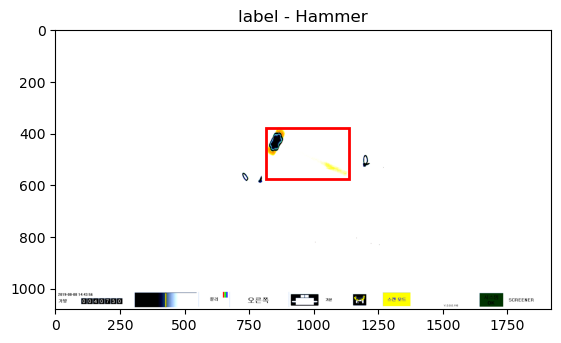

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


torch.Size([3, 1080, 1920]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (852, 338, 277, 274)


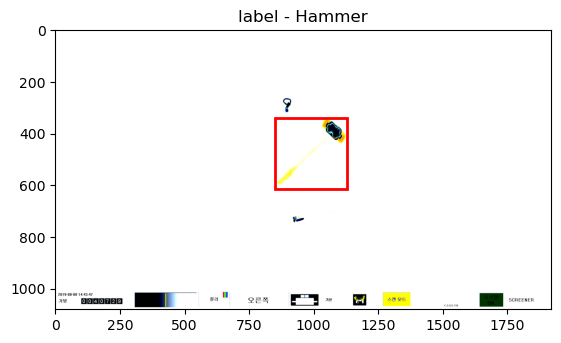

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


torch.Size([3, 1080, 1920]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (754, 336, 193, 322)


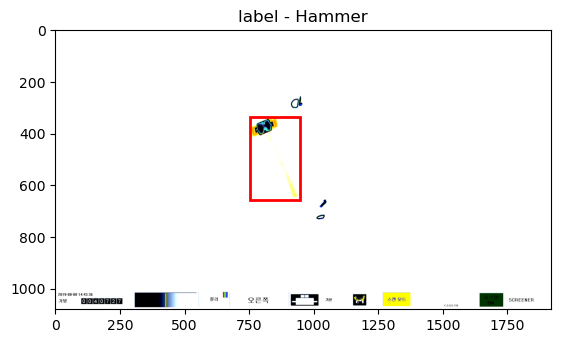

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


torch.Size([3, 1080, 1920]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (813, 375, 332, 137)


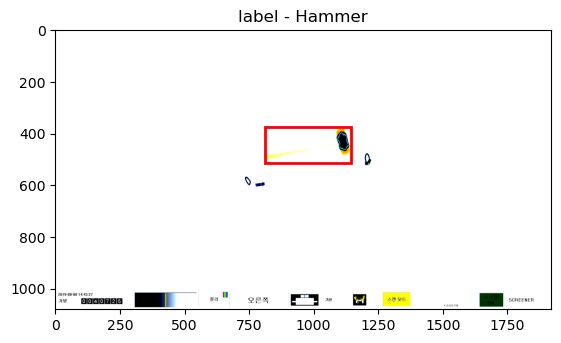

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


torch.Size([3, 1080, 1920]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (829, 376, 111, 244)


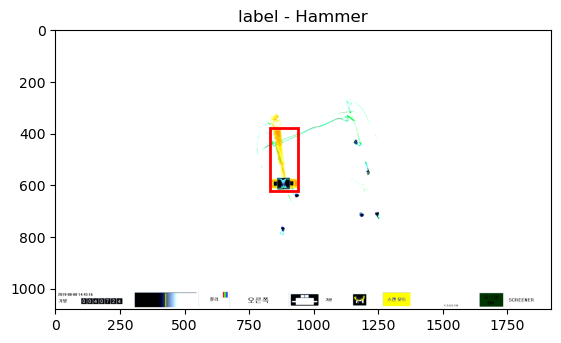

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


torch.Size([3, 1080, 1920]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (1047, 418, 327, 176)


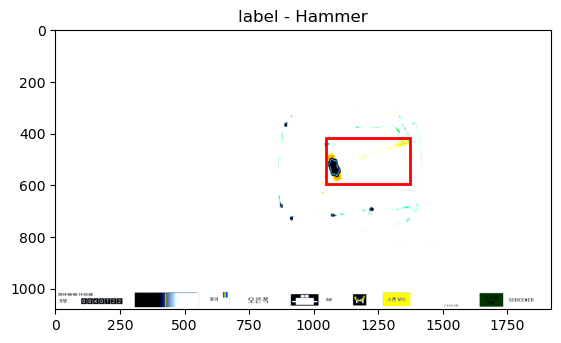

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


torch.Size([3, 1080, 1920]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (976, 396, 263, 282)


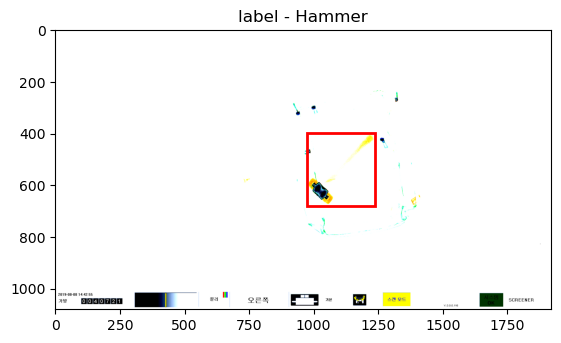

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


torch.Size([3, 1080, 1920]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (862, 382, 322, 205)


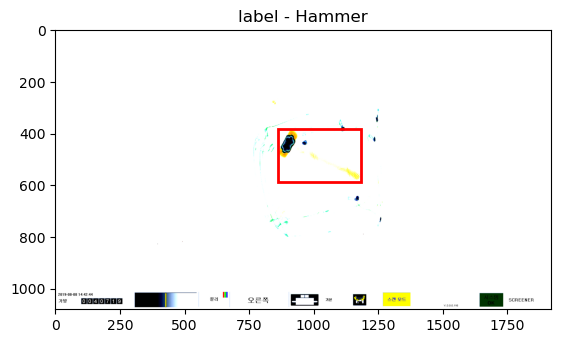

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


torch.Size([3, 1080, 1920]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (751, 349, 282, 257)


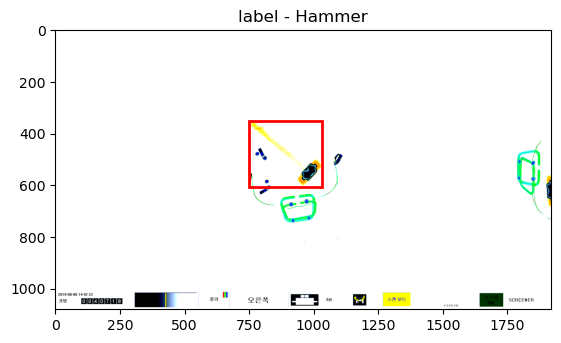

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


torch.Size([3, 1080, 1920]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (781, 558, 330, 130)


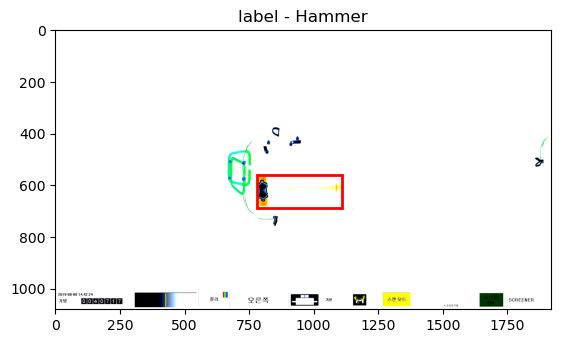

In [39]:
for i in range(1210, 1220):
    imgTS, targetDict = trainDS[i]  ## <== __getitem__(indx)
    print(imgTS.shape, targetDict.keys())
    # - 라벨 정보 추출
    label = targetDict['labels'].item()

    # - 객체 위치 정보 추출
    lx, ly, rx, ry = [round(data.item()) for data in targetDict['boxes'].reshape(-1)]
    w, h = rx - lx, ry - ly

    print(f'lx, ly, w, h => {lx, ly, w, h}')
    ## 시각화 및 바운딩 박스
    plt.imshow(imgTS.permute(1, 2, 0))
    plt.title(f'label - {IDX_TO_CATEGORY[label]}')

    ## 바운딩 박스 추가
    ax = plt.gca()  #- get current axis
    ax.add_patch(patches.Rectangle((lx, ly), w, h, color='red', linewidth=2, fill=False))

    plt.show()

[3] 모델 정의 및 설계<hr>
- 모델 네트워크 구성
    * Backbone Network : VGG16  # 캡쳐 부분만 사용 - 피쳐
    * Nect Network : RPN # 객체가 있을 만한 영역 후보 생성
    * Head Network : Faster R-CNN # 각 후보 영역에 대해 실제 객체의 클래스를 분류하고 경계상자를 예측


In [43]:
## 모델 관련 모듈 로딩
from torchvision.models import vgg16, VGG16_Weights             ## 성능 개선 위해 변경 가능 
from torchvision.models.detection import rpn, FasterRCNN
from torchvision import ops

In [44]:
## --------------------------------------------------------------
## 모델 관련 설정들
## --------------------------------------------------------------

## - Backbone Network 관련
WEIGHTS     = VGG16_Weights.DEFAULT
BACKBONE    = vgg16(weights=WEIGHTS).features
BACKBONE.out_channels = 512
## vgg의 마지막 채널이 512임

## - Neck Network 관련 
## 앵커 생성자 : 이미지 위에 고정된 크기/비율의 앵커 박스 자동 생성
##             RPN(Region Proposal Network) 입력으로 사용
##            - sizes : 각 피처맵 위치에서 생성할 앵커 박스 기본 크기
##            - aspect_ratios :각 크기별로 만들 앵커 박스 종횡비 (가로:세로 비율)
anchor_generator = rpn.AnchorGenerator(
    sizes=((32, 64, 128, 256, 512),),
    aspect_ratios=((0.5, 1.0, 2.0),)
)

## ROI 생성 인스턴스 : 다단계 피처맵에서 객체 영역(RoI) 추출 후 고정 크기 변환 연산 수행 인스턴스 
##                 - featmap_names : 어떤 피처맵 사용할지 지정 
##                 - output_size   : RoI Align 통해 얻고자 하는 출력 크기. (7, 7) 또는 (14, 14)
##                 - sampling_ratio: RoI 내부에서 서브 픽셀 위치를 샘플링할 때 사용할 포인트 수 
##                                   2는 각 셀당 2×2 지점 샘플링
roi_pooler = ops.MultiScaleRoIAlign(
    featmap_names=["0"],
    output_size=(7, 7),
    sampling_ratio=2
)


[5] 학습 준비 <hr>

In [45]:
## 학습관련 설정 값 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 10
TBATCH_SIZE = 4
VBATCH_SIZE = 1



In [48]:
## 데이터셋 관련 인스턴스 생성 
TRAIN_DL = DataLoader( trainDS, batch_size=TBATCH_SIZE, shuffle=True, drop_last=True, collate_fn=collator)
VALID_DL  = DataLoader( validDS,  batch_size=VBATCH_SIZE, shuffle=True, drop_last=True, collate_fn=collator )

In [49]:
TRAIN_DL

In [50]:

## 인스턴스 생성 
MODEL = FasterRCNN( backbone=BACKBONE,
                    num_classes=3,
                    rpn_anchor_generator=anchor_generator,
                    box_roi_pool=roi_pooler
                    ).to(DEVICE)



In [51]:
from torch import optim


params = [p for p in MODEL.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.0005)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [ ]:
from tqdm import tqdm

## 학습 진행
for epoch in range(1):
    cost = 0.0
    print(f"\n[Epoch {epoch+1}]")
    
    # tqdm 적용
    for idx, (images, targets) in enumerate(tqdm(TRAIN_DL, desc="Training")):
        ## GPU에 이미지와 타겟 정보 위치
        images = list(image.to(DEVICE) for image in images)
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        if idx == 4:  # 디버깅용이라면 유지, 실전에서는 제거
            break

        ## 모델 학습
        loss_dict = MODEL(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        cost += losses.item()  # loss 값을 tensor → float로

    lr_scheduler.step()
    cost = cost / len(TRAIN_DL)
    print(f"Epoch : {epoch+1:4d}, Cost : {cost:.3f}")



[Epoch 1]


Training:   0%|          | 0/825 [00:00<?, ?it/s]

: 

In [ ]:
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
from torchvision.transforms.functional import to_pil_image

## 객체에 박스 그리기.
def draw_bbox(ax, box, text, color):
    ax.add_patch(
        plt.Rectangle(
            xy=(box[0], box[1]),
            width=box[2] - box[0],
            height=box[3] - box[1],
            fill=False,
            edgecolor=color,
            linewidth=2,
        )
    )
    #객체 위치에 라벨 달기
    ax.annotate(
        text=text,
        xy=(box[0] - 5, box[1] - 5),
        color=color,
        weight="bold",
        fontsize=13,
    )
 
 
## 검증진행
## 예측 결과에 대한 신뢰도. 0.5 이상이면 중간 이상의 신뢰도
threshold = 0.5
categories = testDS.categories
with torch.no_grad():
    MODEL.eval()
    idx = 0
    for images, targets in TEST_DL:
        idx += 1
        if idx == 5:
            break
        # 예측진행
        images = [image.to(DEVICE) for image in images] ## GPU적용. cpu면 없어도됨
        
        outputs = MODEL(images)
        # 각 이미지에 대한 예측 결과 반환
        ## -> boxes : 예측된 경계상자 좌표
        ## -> labels: 예측 박스의 클래스 인덱스
        ## -> scores : 예측 박스에 대한 신뢰도(확률) 점수, 값의 범위는 0.0~1.0
        ## 예측 객체 위치, 라벨, 점수 저장 변수들
        boxes = outputs[0]["boxes"].to("cpu").numpy()
        labels = outputs[0]["labels"].to("cpu").numpy()
        scores = outputs[0]["scores"].to("cpu").numpy()
        
        
        boxes = boxes[scores >= threshold].astype(np.int32)
        labels = labels[scores >= threshold]
        scores = scores[scores >= threshold]

        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(1, 1, 1)
        plt.imshow(to_pil_image(images[0]))

        for box, label, score in zip(boxes, labels, scores):
            draw_bbox(ax, box, f"{categories[label]} - {score:.4f}", "red")

        tboxes = targets[0]["boxes"].numpy()
        tlabels = targets[0]["labels"].numpy()
        for box, label in zip(tboxes, tlabels):
            draw_bbox(ax, box, f"{categories[label]}", "blue")
            
        plt.show()

In [ ]:
## 검증 진행에 따른 성능평가
## -> 정확도, 정밀도, 재현율


import numpy as np
from pycocotools.cocoeval import COCOeval


with torch.no_grad():
    MODEL.eval()
    coco_detections = []
    
    idx = 0
    for images, targets in TEST_DL:
        idx += 1
        if idx == 5:
            break
        images = [img.to(DEVICE) for img in images]
        outputs = MODEL(images)
        ## 예측값
        
        for i in range(len(targets)):
            ## 정답
            image_id = targets[i]["image_id"].data.cpu().numpy().tolist()[0]
            
            ## 예측값
            boxes = outputs[i]["boxes"].data.cpu().numpy()
            boxes[:, 2] = boxes[:, 2] - boxes[:, 0]
            boxes[:, 3] = boxes[:, 3] - boxes[:, 1]
            scores = outputs[i]["scores"].data.cpu().numpy()
            labels = outputs[i]["labels"].data.cpu().numpy()

            for instance_id in range(len(boxes)):
                box = boxes[instance_id, :].tolist()
                prediction = np.array(
                    [
                        image_id,
                        box[0],
                        box[1],
                        box[2],
                        box[3],
                        float(scores[instance_id]),
                        int(labels[instance_id]),
                    ]
                )
                coco_detections.append(prediction)

    ##예측정보 저장
    coco_detections = np.asarray(coco_detections)
    coco_gt = TEST_DL.dataset.coco                  ## 정답
    coco_dt = coco_gt.loadRes(coco_detections)      ## 예측
    
    coco_evaluator = COCOeval(coco_gt, coco_dt, iouType="bbox")
    coco_evaluator.evaluate()
    coco_evaluator.accumulate()
    coco_evaluator.summarize()
    
    ## 성능평가
    ## 정답박스와 예측박스 비교방식 ==> IOU
    ## p 533
    